# Reproducing Colquhoun, Hawkes, Merlushkin & Edmonds (1997)

**Reference:** Colquhoun D, Hawkes AG, Merlushkin A, Edmonds B (1997).  
"Properties of single ion channel currents elicited by a pulse of agonist concentration or voltage."  
_Phil Trans R Soc Lond A_ **355**, 1743–1786.

This notebook reproduces, as closely as possible, the tables and figures of the first-latency
section of CHME97 using the `scalcs.firstlatency` module.  

**Physical scenario:** The channel starts in equilibrium shut occupancies at
zero agonist ($c_0 = 0$). At $t = 0$ the concentration steps to $c_1 = 1$ mM.  
The _first-latency pdf_ $f_L(t)$ is the probability density of the time to the
first opening.

**Three approximation levels:**

| Level | Validity | Description |
|---|---|---|
| Ideal | all $t$ | No missed events; $f_L(t) = \phi_{shut}\,e^{Q_{FF}t}(-Q_{FF})\mathbf{u}$ |
| Asymptotic | $t \gg t_{res}$ | HJC missed-event correction; valid far from $t_{res}$ |
| Exact | $t_{res} \le t < 3t_{res}$ | Exact HJC correction near $t_{res}$, asymptotic beyond |

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math

from scalcs.samples.samples import CHME97
from scalcs import firstlatency as fl
from scalcs import qmatlib as qm

## 1. Mechanism — Table 1 equivalent

The 5-state "flip" model with desensitisation used in CHME97.  
States: **A2R\*** (open, $k_A = 1$); **A2D**, **A2R**, **AR**, **R** (shut, $k_F = 4$).

| Rate | From | To | Value (s⁻¹ or M⁻¹s⁻¹) |
|---|---|---|---|
| $\alpha$ | A2R\* | A2R | 916 s⁻¹ |
| $\beta$ | A2R | A2R\* | 46.5 s⁻¹ |
| $k_{-D}$ | A2D | A2R | 1.8 s⁻¹ |
| $k_{+D}$ | A2R | A2D | 8.4 s⁻¹ |
| $k_{+2}$ | AR | A2R | $5.0 \times 10^6$ M⁻¹s⁻¹ |
| $2k_{-2}$ | A2R | AR | 9.4 s⁻¹ |
| $2k_{+1}$ | R | AR | $10.0 \times 10^6$ M⁻¹s⁻¹ |
| $k_{-1}$ | AR | R | 4.7 s⁻¹ |

In [2]:
# Pre-jump: c0 = 0 mM  (channels in equilibrium in unliganded shut states)
c0 = 0.0
mec0 = CHME97()
mec0.set_eff('c', c0)

# Post-jump: c1 = 1 mM
c1 = 1e-3   # 1 mM in M
mec1 = CHME97()
mec1.set_eff('c', c1)

print(f"States:  k = {mec1.k}  (kA = {mec1.kA} open, kF = {mec1.kF} shut)")
print()
print("State names (order in Q matrix):")
for i, s in enumerate(mec1.States):
    print(f"  {i}: {s.name}  (class {s.statetype})")

States:  k = 5  (kA = 1 open, kF = 4 shut)

State names (order in Q matrix):
  0: A2R*  (class A)
  1: A2R  (class B)
  2: A2D  (class B)
  3: AR  (class C)
  4: R  (class C)


## 2. Q matrix at c₁ = 1 mM

The full generator matrix at post-jump concentration.

In [3]:
names = [s.name for s in mec1.States]
Q = mec1.Q

print("Q matrix at c = 1 mM  (s⁻¹)")
print()
# Header
header = f"{'':10s}" + "".join(f"{n:>12s}" for n in names)
print(header)
print("-" * len(header))
for i, row_name in enumerate(names):
    row = f"{row_name:10s}" + "".join(f"{Q[i,j]:12.2f}" for j in range(len(names)))
    print(row)

print()
print("Submatrix dimensions:")
print(f"  QAA (open–open):   {mec1.QAA.shape}")
print(f"  QFF (shut–shut):   {mec1.QFF.shape}")
print(f"  QAF (open→shut):   {mec1.QAF.shape}")
print(f"  QFA (shut→open):   {mec1.QFA.shape}")

Q matrix at c = 1 mM  (s⁻¹)

                  A2R*         A2R         A2D          AR           R
----------------------------------------------------------------------
A2R*           -916.00      916.00        0.00        0.00        0.00
A2R              46.50      -64.30        8.40        9.40        0.00
A2D               0.00        1.80       -1.80        0.00        0.00
AR                0.00     5000.00        0.00    -5004.70        4.70
R                 0.00        0.00        0.00    10000.00   -10000.00

Submatrix dimensions:
  QAA (open–open):   (1, 1)
  QFF (shut–shut):   (4, 4)
  QAF (open→shut):   (1, 4)
  QFA (shut→open):   (4, 1)


## 3. Equilibrium at c₀ = 0: initial vector φₛₕᵤₜ

At zero concentration all probability is in the unliganded state **R**.  
The HJC initial vector is the equilibrium occupancy of shut states at $c_0$:  
$$\phi_{shut} = \pi(Q_{c_0})[k_A:]$$

In [4]:
pinf0 = qm.pinf(mec0.Q)
phi_shut = pinf0[mec0.kA:]

print("Equilibrium occupancies at c0 = 0 mM:")
for i, s in enumerate(mec0.States):
    print(f"  pi({s.name}) = {pinf0[i]:.6f}")
print()
print("Initial vector phi_shut (shut states only):")
shut_names = [s.name for s in mec0.States[mec0.kA:]]
for n, p in zip(shut_names, phi_shut):
    print(f"  phi({n}) = {p:.6f}")
print(f"  sum = {phi_shut.sum():.6f}  (must be 1.0 at c=0)")

Equilibrium occupancies at c0 = 0 mM:
  pi(A2R*) = -0.000000
  pi(A2R) = -0.000000
  pi(A2D) = -0.000000
  pi(AR) = -0.000000
  pi(R) = 1.000000

Initial vector phi_shut (shut states only):
  phi(A2R) = -0.000000
  phi(A2D) = -0.000000
  phi(AR) = -0.000000
  phi(R) = 1.000000
  sum = 1.000000  (must be 1.0 at c=0)


## 4. Eigenvalues of Q at c₁ = 1 mM

The eigenvalues of $-Q$ determine the time constants of all relaxation processes.  
One eigenvalue is exactly zero (stationary distribution).

In [5]:
eigs_Q, _ = qm.eigs_sorted(-mec1.Q)

print("Eigenvalues of −Q at c = 1 mM  (CHME97, § Table equivalent)")
print(f"{'#':>4s}  {'Eigenvalue (s⁻¹)':>20s}  {'Time constant (ms)':>20s}")
print("-" * 52)
for i, ev in enumerate(eigs_Q):
    tau_ms = (1.0 / ev * 1000) if ev > 1e-10 else float('inf')
    tau_str = f"{tau_ms:.4f}" if ev > 1e-10 else "∞ (stationary)"
    print(f"{i+1:>4d}  {ev:>20.4f}  {tau_str:>20s}")

Eigenvalues of −Q at c = 1 mM  (CHME97, § Table equivalent)
   #      Eigenvalue (s⁻¹)    Time constant (ms)
----------------------------------------------------
   1                0.0000        ∞ (stationary)
   2                9.7757              102.2942
   3              962.8000                1.0386
   4             5004.8242                0.1998
   5            10009.4001                0.0999


## 5. Ideal first-latency pdf components

The ideal pdf (no missed events) is a sum of $k_F = 4$ exponentials:  
$$f_L(t) = \sum_{i=1}^{k_F} a_i\,\lambda_i\,e^{-\lambda_i t}$$
where $\lambda_i$ are eigenvalues of $-Q_{FF}$ at $c_1$ and $a_i$ are areas ($\sum a_i = 1$).

Corresponds to CHME97 equation (2.4) and associated table.

In [6]:
eigs_ideal, areas_ideal = fl.ideal_components(mec1.QFF, phi_shut)

# Sort by eigenvalue (ascending = slowest first)
idx = np.argsort(eigs_ideal)
ev_s = eigs_ideal[idx]
ar_s = areas_ideal[idx]
tau_s = 1.0 / ev_s

print("Ideal first-latency pdf components  (c₁ = 1 mM, no missed events)")
print(f"{'#':>4s}  {'λ (s⁻¹)':>14s}  {'τ (ms)':>12s}  {'Area a':>12s}")
print("-" * 50)
for i in range(len(ev_s)):
    print(f"{i+1:>4d}  {ev_s[i]:>14.4f}  {tau_s[i]*1000:>12.4f}  {ar_s[i]:>12.6f}")
print("-" * 50)
print(f"{'Sum':>4s}  {'':>14s}  {'':>12s}  {ar_s.sum():>12.6f}")

Ideal first-latency pdf components  (c₁ = 1 mM, no missed events)
   #         λ (s⁻¹)        τ (ms)        Area a
--------------------------------------------------
   1          1.5167      659.3045      0.161891
   2         55.0790       18.1557      0.852199
   3       5004.8042        0.1998     -0.018753
   4      10009.4000        0.0999      0.004663
--------------------------------------------------
 Sum                                    1.000000


## 6. Asymptotic first-latency pdf — tᴾᵉˢ = 0.7 ms

The HJC asymptotic approximation uses the roots $s_i$ of $\det[W_F(s)] = 0$,  
where $W_F(s) = sI - Q_{FF} - Q_{FA}(sI - Q_{AA})^{-1}Q_{AF}\,e^{-(sI-Q_{AA})t_{res}}$.

The roots are the same as for the ordinary HJC shut-time pdf; only the
area coefficients change to reflect the non-equilibrium initial vector $\phi_{shut}$.

$$f_L(t) = 0 \quad (t \le t_{res})$$
$$f_L(t) = \sum_{i=1}^{k_F} a_i\,|s_i|\,e^{s_i(t - t_{res})} \quad (t > t_{res})$$

Corresponds to CHME97 equation (2.14) and Table 2.

In [7]:
tres = 7e-4   # 0.7 ms

roots = fl.asymptotic_roots(tres, mec1)
areas_asym = fl.asymptotic_areas(tres, roots, phi_shut, mec1)
tau_asym = -1.0 / roots

# Sort by |root| ascending (slowest component first)
idx = np.argsort(np.abs(roots))
roots_s   = roots[idx]
tau_s     = tau_asym[idx]
areas_s   = areas_asym[idx]

print(f"Asymptotic first-latency pdf components  (c₁ = 1 mM, t_res = {tres*1000:.1f} ms)")
print(f"{'#':>4s}  {'Root s (s⁻¹)':>16s}  {'τ (ms)':>12s}  {'Area a':>12s}")
print("-" * 52)
for i in range(len(roots_s)):
    print(f"{i+1:>4d}  {roots_s[i]:>16.4f}  {tau_s[i]*1000:>12.4f}  {areas_s[i]:>12.6f}")
print("-" * 52)
print(f"{'Sum':>4s}  {'':>16s}  {'':>12s}  {areas_s.sum():>12.6f}")
print()
print(f"Note: sum < 1 reflects HJC missed-event correction (deficit = {1 - areas_s.sum():.6f})")

Asymptotic first-latency pdf components  (c₁ = 1 mM, t_res = 0.7 ms)
   #      Root s (s⁻¹)        τ (ms)        Area a
----------------------------------------------------
   1           -1.3209      757.0764      0.277363
   2          -33.0810       30.2289      0.729932
   3        -5004.4856        0.1998     -0.009545
   4       -10009.3981        0.0999      0.001928
----------------------------------------------------
 Sum                                      0.999678

Note: sum < 1 reflects HJC missed-event correction (deficit = 0.000322)


### Comparison: ideal vs asymptotic time constants

At $t_{res} = 0.7$ ms, the two slowest components (659 ms and 18 ms) are
barely affected by the missed-event correction, whereas the fastest component
($\tau \approx t_{res}$) is significantly modified.

In [8]:
# Re-sort ideal by eigenvalue to pair with asymptotic by index
eigs_s, areas_ideal_s = fl.ideal_components(mec1.QFF, phi_shut)
idx_i = np.argsort(eigs_s)
eigs_s = eigs_s[idx_i]
areas_ideal_s = areas_ideal_s[idx_i]

print("Ideal vs Asymptotic comparison (sorted slowest→fastest)")
print()
print(f"{'#':>3s}  {'Ideal λ (s⁻¹)':>16s}  {'Ideal τ (ms)':>14s}  "
      f"{'Asym root (s⁻¹)':>18s}  {'Asym τ (ms)':>14s}")
print("-" * 72)
for i in range(mec1.kF):
    print(f"{i+1:>3d}  {eigs_s[i]:>16.4f}  {1000/eigs_s[i]:>14.4f}  "
          f"{roots_s[i]:>18.4f}  {tau_s[i]*1000:>14.4f}")

Ideal vs Asymptotic comparison (sorted slowest→fastest)

  #     Ideal λ (s⁻¹)    Ideal τ (ms)     Asym root (s⁻¹)     Asym τ (ms)
------------------------------------------------------------------------
  1            1.5167        659.3045             -1.3209        757.0764
  2           55.0790         18.1557            -33.0810         30.2289
  3         5004.8042          0.1998          -5004.4856          0.1998
  4        10009.4000          0.0999         -10009.3981          0.0999


## 7. Exact pdf gamma coefficients

The exact HJC correction for $t_{res} \le t < 3t_{res}$ requires the gamma
coefficients $g_{00}$, $g_{10}$, $g_{11}$ from the spectral decomposition of $Q$  
(CHME97 equations 3.20–3.22; Hawkes, Jalali & Colquhoun 1992 §3).

$$f_0(t-t_{res}) = \sum_j g_{00,j}\,e^{-\lambda_j(t-t_{res})}$$

These coefficients fold the full $k\times k$ eigenstructure into scalars via the
initial vector $\phi_{shut}$.

In [9]:
eigvals, g00, g10, g11 = fl.gamma_coefficients(tres, phi_shut, mec1)

# Sort by eigenvalue of -Q ascending (first ≈ 0)
idx_g = np.argsort(eigvals)
ev_g = eigvals[idx_g]
g00_s = g00[idx_g]
g10_s = g10[idx_g]
g11_s = g11[idx_g]

print(f"Gamma coefficients  (t_res = {tres*1000:.1f} ms)")
print(f"{'#':>3s}  {'λ_j (s⁻¹)':>14s}  {'g00_j':>14s}  {'g10_j':>14s}  {'g11_j':>14s}")
print("-" * 65)
for i in range(len(ev_g)):
    print(f"{i+1:>3d}  {ev_g[i]:>14.4f}  {g00_s[i]:>14.4f}  {g10_s[i]:>14.4f}  {g11_s[i]:>14.4f}")

Gamma coefficients  (t_res = 0.7 ms)
  #       λ_j (s⁻¹)           g00_j           g10_j           g11_j
-----------------------------------------------------------------
  1          0.0000          4.2819         16.5975         18.3349
  2          9.7757         19.0188        -17.3040        364.5443
  3        962.8000          1.6413          0.7552        -38.4713
  4       5004.8242        -49.5324         -0.0548          0.5235
  5      10009.4001         24.5904          0.0061         -0.0001


## 8. Spot-check numerical values at selected time points

Direct comparison of all three pdf levels at $t = 1$ ms and $t = 10$ ms.

In [10]:
checkpoints = [0.8e-3, 1.0e-3, 1.4e-3, 5.0e-3, 10.0e-3, 50.0e-3]

print(f"Pdf values at selected time points  (t_res = {tres*1000:.1f} ms)")
print(f"{'t (ms)':>10s}  {'Ideal (s⁻¹)':>14s}  {'Asymptotic (s⁻¹)':>18s}  {'Exact (s⁻¹)':>14s}  {'Asym/Exact':>12s}")
print("-" * 76)
for t in checkpoints:
    fi = float(fl.ideal_pdf(t, mec1.QFF, phi_shut))
    fa = float(fl.asymptotic_pdf(t, tres, tau_asym, areas_asym))
    fe = float(fl.exact_pdf(t, tres, roots, areas_asym, eigvals, g00, g10, g11))
    ratio = fa/fe if fe > 0 else float('nan')
    print(f"{t*1000:>10.2f}  {fi:>14.4f}  {fa:>18.4f}  {fe:>14.4f}  {ratio:>12.6f}")

Pdf values at selected time points  (t_res = 0.7 ms)
    t (ms)     Ideal (s⁻¹)    Asymptotic (s⁻¹)     Exact (s⁻¹)    Asym/Exact
----------------------------------------------------------------------------
      0.80         43.4634              2.5679          3.7822      0.678944
      1.00         44.0408             14.5891         14.6592      0.995212
      1.40         43.6150             22.5397         22.5392      1.000025
      5.00         35.8826             21.3094         21.3094      1.000000
     10.00         27.3015             18.1139         18.1139      1.000000
     50.00          3.2164              5.0701          5.0701      1.000000


## 9. Main figure: ideal, asymptotic and exact pdfs (log time axis)

Reproduces the main figure of the CHME97 first-latency section.  
The vertical dashed line marks $t = t_{res}$.  
Note the discrepancy between asymptotic (dashed) and exact (solid) for $t < 3t_{res}$.

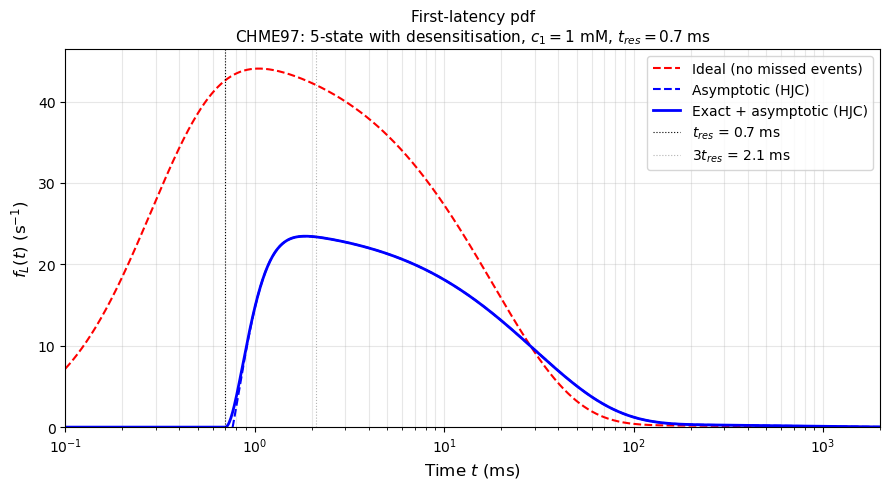

In [11]:
# Time axis: 0.1 ms to 2 s, log-spaced
tstart = 1e-4
tend   = 2.0
npts   = 1000
tseq   = np.logspace(math.log10(tstart), math.log10(tend), npts)

# Evaluate
ipdf = fl.ideal_pdf(tseq, mec1.QFF, phi_shut)
apdf = fl.asymptotic_pdf(tseq, tres, tau_asym, areas_asym)
epdf = fl.exact_pdf(tseq, tres, roots, areas_asym, eigvals, g00, g10, g11)

fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogx(tseq * 1000, ipdf, 'r--', lw=1.5, label='Ideal (no missed events)')
ax.semilogx(tseq * 1000, apdf, 'b--', lw=1.5, label='Asymptotic (HJC)')
ax.semilogx(tseq * 1000, epdf, 'b-',  lw=2.0, label='Exact + asymptotic (HJC)')

# Mark tres
ax.axvline(tres * 1000, color='k', lw=0.8, ls=':', label=f'$t_{{res}}$ = {tres*1000:.1f} ms')
ax.axvline(3 * tres * 1000, color='grey', lw=0.8, ls=':', alpha=0.6,
           label=f'$3t_{{res}}$ = {3*tres*1000:.1f} ms')

ax.set_xlabel('Time $t$ (ms)', fontsize=12)
ax.set_ylabel('$f_L(t)$ (s$^{-1}$)', fontsize=12)
ax.set_title('First-latency pdf\nCHME97: 5-state with desensitisation, $c_1 = 1$ mM, $t_{res} = 0.7$ ms',
             fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim([tstart * 1000, tend * 1000])
ax.set_ylim(bottom=0)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Detail near $t_{res}$: exact correction

Linear time axis, zoomed to the region $[t_{res}, 3t_{res}]$, where the exact
HJC correction differs substantially from the asymptotic approximation.  
Reproduces the inset of CHME97 Figure (first-latency panel).

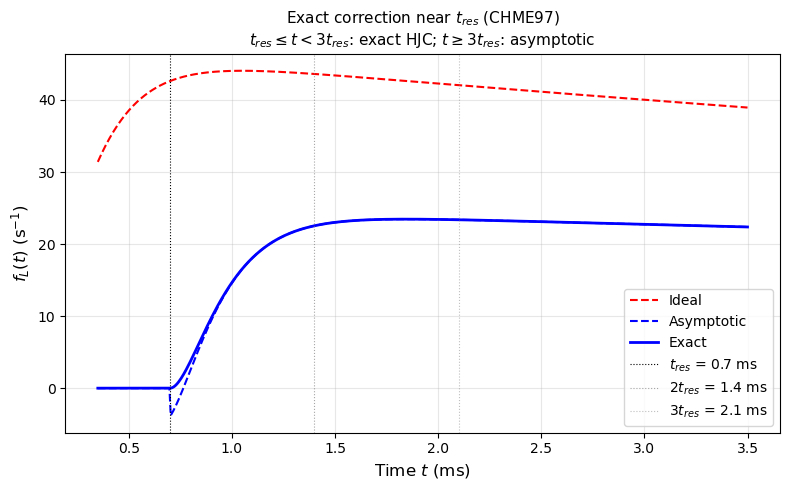

In [12]:
# Linear time axis around tres
t_lin = np.linspace(0.5 * tres, 5.0 * tres, 500)

ipdf_lin = fl.ideal_pdf(t_lin, mec1.QFF, phi_shut)
apdf_lin = fl.asymptotic_pdf(t_lin, tres, tau_asym, areas_asym)
epdf_lin = fl.exact_pdf(t_lin, tres, roots, areas_asym, eigvals, g00, g10, g11)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t_lin * 1000, ipdf_lin, 'r--', lw=1.5, label='Ideal')
ax.plot(t_lin * 1000, apdf_lin, 'b--', lw=1.5, label='Asymptotic')
ax.plot(t_lin * 1000, epdf_lin, 'b-',  lw=2.0, label='Exact')

ax.axvline(tres * 1000,       color='k',    lw=0.8, ls=':',
           label=f'$t_{{res}}$ = {tres*1000:.1f} ms')
ax.axvline(2 * tres * 1000,   color='grey', lw=0.8, ls=':', alpha=0.7,
           label=f'$2t_{{res}}$ = {2*tres*1000:.1f} ms')
ax.axvline(3 * tres * 1000,   color='grey', lw=0.8, ls=':', alpha=0.5,
           label=f'$3t_{{res}}$ = {3*tres*1000:.1f} ms')

ax.set_xlabel('Time $t$ (ms)', fontsize=12)
ax.set_ylabel('$f_L(t)$ (s$^{-1}$)', fontsize=12)
ax.set_title(r'Exact correction near $t_{res}$ (CHME97)'
             '\n'
             r'$t_{res} \leq t < 3t_{res}$: exact HJC; $t \geq 3t_{res}$: asymptotic',
             fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Effect of time resolution $t_{res}$

How sensitive is the first-latency pdf to the imposed dead time?  
Compare asymptotic pdfs at $t_{res} = 0, 0.1, 0.4, 0.7, 2.0$ ms.

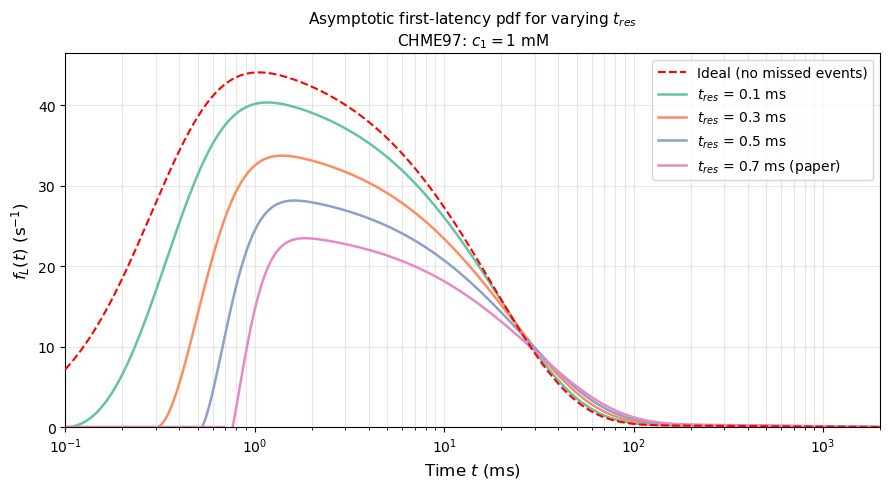

In [13]:
tres_values = [0.0001, 0.0003, 0.0005, 0.0007]   # 0.1, 0.3, 0.5, 0.7 ms
labels = ['$t_{res}$ = 0.1 ms', '$t_{res}$ = 0.3 ms',
          '$t_{res}$ = 0.5 ms', '$t_{res}$ = 0.7 ms (paper)']
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']

fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogx(tseq * 1000, ipdf, 'r--', lw=1.5, label='Ideal (no missed events)', zorder=10)

for tr, lab, col in zip(tres_values, labels, colors):
    r = fl.asymptotic_roots(tr, mec1)
    a = fl.asymptotic_areas(tr, r, phi_shut, mec1)
    tau_r = -1.0 / r
    ap = fl.asymptotic_pdf(tseq, tr, tau_r, a)
    ax.semilogx(tseq * 1000, ap, color=col, lw=1.8, label=lab)

ax.set_xlabel('Time $t$ (ms)', fontsize=12)
ax.set_ylabel('$f_L(t)$ (s$^{-1}$)', fontsize=12)
ax.set_title('Asymptotic first-latency pdf for varying $t_{res}$\nCHME97: $c_1 = 1$ mM',
             fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim([tstart * 1000, tend * 1000])
ax.set_ylim(bottom=0)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Summary table: area sums and mean first latency

The mean first latency is $\langle t_L \rangle = \sum_i a_i \tau_i + t_{res}$  
(for the asymptotic pdf; the ideal mean is $\sum_i a_i / \lambda_i$).

In [14]:
# Ideal mean
eigs_i, areas_i = fl.ideal_components(mec1.QFF, phi_shut)
mean_ideal_ms = np.sum(areas_i / eigs_i) * 1000

print("Mean first latency")
print(f"  Ideal:            {mean_ideal_ms:.4f} ms  (sum_i a_i / lambda_i)")
print()
print(f"{'t_res (ms)':>12s}  {'Sum(areas)':>12s}  {'Mean_asym (ms)':>16s}")
print("-" * 44)
for tr in [0.0001, 0.0003, 0.0005, 0.0007]:
    r = fl.asymptotic_roots(tr, mec1)
    a = fl.asymptotic_areas(tr, r, phi_shut, mec1)
    tau_r = -1.0 / r
    mean_asym_ms = (np.sum(a * tau_r) + tr) * 1000
    print(f"{tr*1000:>12.2f}  {a.sum():>12.6f}  {mean_asym_ms:>16.4f}")

Mean first latency
  Ideal:            122.2043 ms  (sum_i a_i / lambda_i)

  t_res (ms)    Sum(areas)    Mean_asym (ms)
--------------------------------------------
        0.10      1.000000          134.0029
        0.30      0.999997          161.1040
        0.50      0.999951          193.6538
        0.70      0.999678          232.7479


## 13. Verification: exact equals asymptotic for $t \ge 3t_{res}$

A mathematical property: for $t \ge 3t_{res}$ the exact pdf is identical to the
asymptotic pdf (by construction of the HJC expansion).  Verify numerically.

In [15]:
t_check = np.array([3*tres, 5*tres, 10*tres, 50*tres, 0.1, 0.5])

print(f"Exact vs asymptotic for t >= 3*t_res  (t_res = {tres*1000:.1f} ms)")
print(f"{'t (ms)':>10s}  {'Exact':>14s}  {'Asymptotic':>14s}  {'Rel. diff':>12s}")
print("-" * 56)
for t in t_check:
    fe = float(fl.exact_pdf(t, tres, roots, areas_asym, eigvals, g00, g10, g11))
    fa = float(fl.asymptotic_pdf(t, tres, tau_asym, areas_asym))
    reldiff = abs(fe - fa) / max(abs(fa), 1e-15)
    print(f"{t*1000:>10.3f}  {fe:>14.6f}  {fa:>14.6f}  {reldiff:>12.2e}")

Exact vs asymptotic for t >= 3*t_res  (t_res = 0.7 ms)
    t (ms)           Exact      Asymptotic     Rel. diff
--------------------------------------------------------
     2.100       23.376432       23.376432      0.00e+00
     3.500       22.375624       22.375624      0.00e+00
     7.000       19.967515       19.967515      0.00e+00
    35.000        8.113969        8.113969      0.00e+00
   100.000        1.225452        1.225452      0.00e+00
   500.000        0.189448        0.189448      0.00e+00


## 14. Verification: tres → 0 limit (asymptotic → ideal)

At $t_{res} = 0$ there are no missed events and the asymptotic pdf must recover
the ideal pdf exactly.  Check that roots and areas match.

In [16]:
tres_tiny = 0.0
roots_0   = fl.asymptotic_roots(tres_tiny, mec1)
areas_0   = fl.asymptotic_areas(tres_tiny, roots_0, phi_shut, mec1)
eigs_0, areas_id = fl.ideal_components(mec1.QFF, phi_shut)

# Match by magnitude
idx_r = np.argsort(np.abs(roots_0))
idx_i = np.argsort(eigs_0)

print("t_res = 0: asymptotic roots vs ideal eigenvalues")
print(f"{'#':>3s}  {'Asym |root|':>14s}  {'Ideal lambda':>14s}  {'Rel diff':>12s}")
print("-" * 50)
for j in range(mec1.kF):
    r_j = abs(roots_0[idx_r[j]])
    l_j = eigs_0[idx_i[j]]
    print(f"{j+1:>3d}  {r_j:>14.4f}  {l_j:>14.4f}  {abs(r_j-l_j)/l_j:>12.2e}")

print()
print("t_res = 0: asymptotic areas vs ideal areas")
print(f"{'#':>3s}  {'Asym area':>12s}  {'Ideal area':>12s}")
print("-" * 32)
for j in range(mec1.kF):
    print(f"{j+1:>3d}  {areas_0[idx_r[j]]:>12.6f}  {areas_id[idx_i[j]]:>12.6f}")

t_res = 0: asymptotic roots vs ideal eigenvalues
  #     Asym |root|    Ideal lambda      Rel diff
--------------------------------------------------
  1          1.5167          1.5167      4.32e-14
  2         55.0790         55.0790      5.16e-16
  3       5004.8042       5004.8042      3.63e-16
  4      10009.4000      10009.4000      1.45e-15

t_res = 0: asymptotic areas vs ideal areas
  #     Asym area    Ideal area
--------------------------------
  1      0.161891      0.161891
  2      0.852199      0.852199
  3     -0.018753     -0.018753
  4      0.004663      0.004663
